In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [2]:
data = {
    'temperature_hi': [30.67, 29, 28.67, 27.67, 26, 28.67, 28.67, 28.34, 27, 23.67, 24.67, 28, 26.34, 24.67, 24],
    'temperature_low': [26, 25, 25.67, 24.67, 24.34, 25.67, 26.34, 25.67, 25, 23, 24, 25.67, 24.67, 24, 23.34],
    'humidity': [68.67, 77.67, 69.67, 81, 84.34, 74, 73.34, 75, 80.67, 91.34, 89.67, 76.34, 82.67, 86.67, 89.67],
    'pressure': [1008, 1006.67, 1006.34, 1004, 1003, 1003.67, 1005.67, 1005, 1004, 1005.34, 1005.34, 1007, 1007.67, 1005.34, 1004],
    'rain': [0, 0, 0, 1, 1, 0, 0, 1, 0, 1, 1, 0, 1, 1, 1]
}
df = pd.DataFrame(data)
df.sort_values(by=['rain', 'humidity'], ascending = False)

print(df)


X = df[['temperature_hi', 'temperature_low', 'humidity', 'pressure']]
y = df['rain']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LogisticRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

    temperature_hi  temperature_low  humidity  pressure  rain
0            30.67            26.00     68.67   1008.00     0
1            29.00            25.00     77.67   1006.67     0
2            28.67            25.67     69.67   1006.34     0
3            27.67            24.67     81.00   1004.00     1
4            26.00            24.34     84.34   1003.00     1
5            28.67            25.67     74.00   1003.67     0
6            28.67            26.34     73.34   1005.67     0
7            28.34            25.67     75.00   1005.00     1
8            27.00            25.00     80.67   1004.00     0
9            23.67            23.00     91.34   1005.34     1
10           24.67            24.00     89.67   1005.34     1
11           28.00            25.67     76.34   1007.00     0
12           26.34            24.67     82.67   1007.67     1
13           24.67            24.00     86.67   1005.34     1
14           24.00            23.34     89.67   1004.00     1


In [3]:
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.2f}")

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("Classification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 1.00
Confusion Matrix:
[[2 0]
 [0 1]]
Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         2
           1       1.00      1.00      1.00         1

    accuracy                           1.00         3
   macro avg       1.00      1.00      1.00         3
weighted avg       1.00      1.00      1.00         3



In [4]:
coefficients = model.coef_[0]
feature_names = X.columns
print("Feature Importance:")
for feature, coef in zip(feature_names, coefficients):
    print(f"{feature}: {coef:.2f}")

Feature Importance:
temperature_hi: -0.32
temperature_low: -0.07
humidity: 0.29
pressure: -0.01


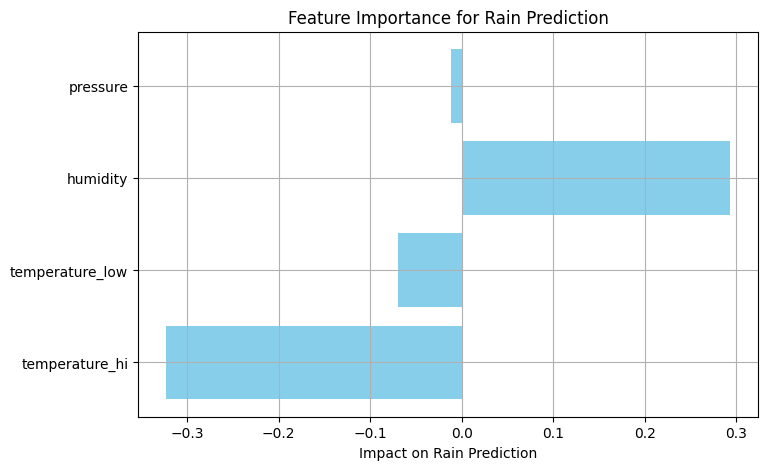

In [5]:
plt.figure(figsize=(8,5))
plt.barh(feature_names, coefficients, color='skyblue')
plt.xlabel('Impact on Rain Prediction')
plt.title('Feature Importance for Rain Prediction')
plt.grid(True)
plt.show()

In [7]:
hi_temp = float(input("Enter today's high temperature: "))
low_temp = float(input("Enter today's low temperature: "))
humidity = float(input("Enter today's humidity (%): "))
pressure = float(input("Enter today's pressure (mbar): "))

input_data = pd.DataFrame({
    'temperature_hi': [hi_temp],
    'temperature_low': [low_temp],
    'humidity': [humidity],
    'pressure': [pressure]
})
prediction = model.predict(input_data)

if prediction[0] == 1:
    print("It is likely to rain today!")
else:
    print("It is unlikely to rain today!")

Enter today's high temperature:  38
Enter today's low temperature:  25
Enter today's humidity (%):  51
Enter today's pressure (mbar):  1014


It is unlikely to rain today!
